<a href="https://colab.research.google.com/github/mrbedoya/ml-2026/blob/main/04_RegresionLogistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresion Logística


**Regresión logística** es una variación que se usa para clasificación binaria (entre 0 y 1).

No es práctico usar una línea recta para estimar probabilidades (que varían entre 0 y 1)

Establece la probabilidad de que la instancia pertenezca a la clase objetivo*

*NO indica que este sea el valor de la variable de respuesta, tal y como es el caso de la regresión lineal



## 1. Librerias y configuraciones previas


In [1]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np


# Almacenar en caché los resultados de funciones en el disco
# ==============================================================================
import joblib


# Gestion de librerias
# ==============================================================================
from importlib import reload


# Matemáticas y estadísticas
# ==============================================================================
import math


# Preprocesado y modelado
# ==============================================================================

#Separar los datos entrenamiento y prueba
from sklearn.model_selection import train_test_split

#Escalar Variables
from sklearn.preprocessing import MinMaxScaler

#Creación de modelo
from sklearn.linear_model import LogisticRegression

#Evaluación del modelo
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)


# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Interuactuar con os y solicitudes desde HTTP
# ==============================================================================
import os
import sys
import requests

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Parametros globales
# ==============================================================================

# URL base de GitHub para el repositorio
GITHUB_BASE_URL = 'https://raw.githubusercontent.com/mrbedoya/ml-2026/main/'

# Nombres de los archivos requeridos
DATASET_FILE_NAME = '02_GermanCredit.csv'
UTILS_FILE_NAME = 'funciones.py'

# Nombres de los directorios para utilidades, datasets y modelos
DATASETS_PATH = 'datasets/'
UTILS_PATH = 'utils/'
MODELS_PATH = 'modelos/'
MODELS_CLASIFICACION_PATH = os.path.join(MODELS_PATH, 'clasificacion')
MODELS_SCALER_PATH = os.path.join(MODELS_PATH, 'scaler')

# URL completa del dataset y utils en GitHub
github_dataset_url = os.path.join(GITHUB_BASE_URL, DATASETS_PATH, DATASET_FILE_NAME)
github_utils_url = os.path.join(GITHUB_BASE_URL, UTILS_PATH, UTILS_FILE_NAME)

# Rutas locales completas de datasets y utils
local_dataset_path = os.path.join(DATASETS_PATH, DATASET_FILE_NAME)
local_utils_path = os.path.join(UTILS_PATH, UTILS_FILE_NAME)

In [3]:
## Cargar datos desde Google Drive
## ==============================================================================

#from google.colab import drive

## Montar Google Drive
#drive.mount('/gdrive')

## Establece el directorio de trabajo dentro de directorio espefíficado en Google Drive
#os.chdir("/gdrive/MyDrive/01_Academia/02_Cursos/20260401_ApredinzajeAutomáticoI_UdeA/")

## Listar archivos de directorio
##!ls

In [4]:
# Funcion local para la carga de archivos
# ==============================================================================

def download_file(url, path, description):
    '''
    Descarga un archivo desde una URL y lo guarda localmente.

    Args:
        url (str): URL del archivo
        path (str): Ruta local de destino
        description (str): Descripción del archivo
    Returns:
        None
    '''
    print(f"Descargando {description} desde: {url}")

    # Realiza una solicitud HTTP GET a la URL proporcionada
    response = requests.get(url)

    # Lanza una excepción si la descarga falla (código de estado HTTP no 200)
    response.raise_for_status()

    # Abre el archivo local en modo de escritura binaria ('wb')
    with open(path, 'wb') as f:
        # Escribe el contenido binario de la respuesta HTTP en el archivo local
        f.write(response.content)

    # Imprime un mensaje confirmando que la descarga fue exitosa y la ruta de guardado
    print(f"{description} descargado exitosamente a: {path}")

In [5]:
# Configuración entorno Colab
# ==============================================================================

# Creación de directorios locales
os.makedirs(DATASETS_PATH, exist_ok=True)
os.makedirs(UTILS_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

# Crear subdirectorios específicos para modelos y escalados
os.makedirs(MODELS_CLASIFICACION_PATH, exist_ok=True)
os.makedirs(MODELS_SCALER_PATH, exist_ok=True)

# Descarga de archivos
download_file(github_dataset_url, local_dataset_path, "dataset")
download_file(github_utils_url, local_utils_path, "funciones")

Descargando dataset desde: https://raw.githubusercontent.com/mrbedoya/ml-2026/main/datasets/02_GermanCredit.csv
dataset descargado exitosamente a: datasets/02_GermanCredit.csv
Descargando funciones desde: https://raw.githubusercontent.com/mrbedoya/ml-2026/main/utils/funciones.py
funciones descargado exitosamente a: utils/funciones.py


## 2. Funciones

In [6]:
## Funciones externas
# ==============================================================================

## Añade la ruta definida en 'UTILS_PATH' al 'sys.path' para que Python pueda encontrar módulos
sys.path.append(UTILS_PATH)

## Importar Funciones externas
from funciones import multiple_plot, plot_roc_curve

## 3. Carga del dataset

In [7]:
#Se crea un dataframe d con los datos obtenidos de archivo de entrada
d=pd.read_csv(local_dataset_path)

In [8]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Customer ID               1000 non-null   int64 
 1   checking_account_status   1000 non-null   object
 2   loan_duration_mo          1000 non-null   int64 
 3   credit_history            1000 non-null   object
 4   purpose                   1000 non-null   object
 5   loan_amount               1000 non-null   int64 
 6   savings_account_balance   1000 non-null   object
 7   time_employed_yrs         1000 non-null   object
 8   payment_pcnt_income       1000 non-null   int64 
 9   gender_status             1000 non-null   object
 10  other_signators           1000 non-null   object
 11  time_in_residence         1000 non-null   int64 
 12  property                  1000 non-null   object
 13  age_yrs                   1000 non-null   int64 
 14  other_credit_outstanding 

## 4. Visualización de datos

### Variables de entrada

In [9]:
#Lista de variables categóricas
catCols = d.select_dtypes(include = ["object", 'category']).columns.tolist()

d[catCols].head(2)

,checking_account_status,credit_history,purpose,savings_account_balance,time_employed_yrs,gender_status,other_signators,property,other_credit_outstanding,home_ownership,job_category,telephone,foreign_worker
0,< 0 DM,critical account - other non-bank loans,radio/television,unknown/none,>= 7 years,male-single,none,real estate,none,own,skilled,yes,yes
1,0 - 200 DM,current loans paid,radio/television,< 100 DM,1 - 4 years,female-divorced/separated/married,none,real estate,none,own,skilled,none,yes


In [10]:
#Lista de variables numéricas

numCols=d.select_dtypes(include = ['float64','int32','int64']).columns.tolist()

d[numCols].head(2)

,Customer ID,loan_duration_mo,loan_amount,payment_pcnt_income,time_in_residence,age_yrs,number_loans,dependents,bad_credit
0,1122334,6,1169,4,4,67,2,1,0
1,6156361,48,5951,2,2,22,1,1,1


In [11]:
##Visualización de frecuencia de instancias para variables categóricas
#multiple_plot(3, d , catCols, None, 'countplot', 'Frecuencia de instancias para variables categóricas',30)

In [12]:
##Visualización de variables numéricas
#multiple_plot(1, d , numCols, None, 'scatterplot', 'Relación entre las variables numéricas',30)

In [13]:
#Eliminar la variable de salida de la lista de variable numéricas
numCols.remove('bad_credit')

### Variable de salida

In [14]:
# Distriución de la variable de salida

d.groupby('bad_credit').bad_credit.count().sort_values(ascending=False)

,bad_credit
bad_credit,
0,700
1,300


In [15]:
##Visualización de la variable de salida
#multiple_plot(1, d , None, 'bad_credit', 'countplot', 'Gráfica de frecuencia de bad Credit',0)

## 5. Transformación de datos

### Creación de variables Dummies

In [16]:
# Aplicación de la función de usuario Dummies: one-hot encoding

d =pd.get_dummies(d, drop_first=1)

d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 50 columns):
 #   Column                                                  Non-Null Count  Dtype
---  ------                                                  --------------  -----
 0   Customer ID                                             1000 non-null   int64
 1   loan_duration_mo                                        1000 non-null   int64
 2   loan_amount                                             1000 non-null   int64
 3   payment_pcnt_income                                     1000 non-null   int64
 4   time_in_residence                                       1000 non-null   int64
 5   age_yrs                                                 1000 non-null   int64
 6   number_loans                                            1000 non-null   int64
 7   dependents                                              1000 non-null   int64
 8   bad_credit                                              100

## 6. Creación del modelo

### Dividir el conjunto de datos

In [17]:
#Se crea una lista con todas las varibles de entrada

vDep = list(d.columns)
vDep.remove('bad_credit')

#Se establece las variables de entrada 'X' y la variable de salida 'y'
X = d.drop(columns ='bad_credit')
y = d['bad_credit']

In [18]:
# Se crean los datasets de entrenamiento y prueba para las variables de entrada y salida

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y.values.reshape(-1,1),
                                        train_size   = 0.8,
                                        random_state = 123,
                                        shuffle      = True
                                    )

### Escalar Variables

In [19]:
#Se establecen las variables numéricas a escalar

#Num_vars se le asigna la lista con las variables numerivas para posteriormente escalarlas
num_vars = numCols

print(num_vars)

['Customer ID', 'loan_duration_mo', 'loan_amount', 'payment_pcnt_income', 'time_in_residence', 'age_yrs', 'number_loans', 'dependents']


In [20]:
#Escalar Variables númericas

pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Se crea un objeto MinMaxScaler
scaler = MinMaxScaler()

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars] = scaler.transform(X_test[num_vars])

X_test[num_vars].head(2)

,Customer ID,loan_duration_mo,loan_amount,payment_pcnt_income,time_in_residence,age_yrs,number_loans,dependents
131,0.7475,0.1176,0.1788,0.6667,0.3333,0.1786,0.3333,0.0000
203,0.4694,0.1176,0.0505,1.0000,0.6667,0.1429,0.0000,0.0000


In [21]:
X_test

,Customer ID,loan_duration_mo,loan_amount,payment_pcnt_income,time_in_residence,age_yrs,number_loans,dependents,checking_account_status_< 0 DM,checking_account_status_> 200 DM or salary assignment,...,property_unknown-none,other_credit_outstanding_none,other_credit_outstanding_stores,home_ownership_own,home_ownership_rent,job_category_skilled,job_category_unemployed-unskilled-non-resident,job_category_unskilled-resident,telephone_yes,foreign_worker_yes
131,0.7475,0.1176,0.1788,0.6667,0.3333,0.1786,0.3333,0.0000,True,False,...,False,True,False,True,False,True,False,False,False,True
203,0.4694,0.1176,0.0505,1.0000,0.6667,0.1429,0.0000,0.0000,True,False,...,False,True,False,True,False,False,False,True,False,True
50,0.7515,0.2941,0.1146,1.0000,0.3333,0.1786,0.0000,0.0000,False,False,...,False,False,False,True,False,False,False,True,False,True
585,0.5191,0.0735,0.0626,1.0000,0.3333,0.1250,0.0000,0.0000,False,False,...,False,True,False,False,True,True,False,False,False,True
138,0.5920,0.3382,0.4602,0.3333,0.3333,0.1429,0.3333,0.0000,False,False,...,False,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,0.7425,0.3824,0.1971,0.3333,0.0000,0.0536,0.0000,0.0000,False,False,...,False,True,False,True,False,True,False,False,False,True
177,0.3700,0.3824,0.3981,1.0000,0.0000,0.6071,0.0000,0.0000,False,False,...,False,False,False,True,False,False,False,False,True,True
657,0.9471,0.1471,0.2049,0.0000,1.0000,0.0536,0.0000,0.0000,True,False,...,True,True,False,False,False,True,False,False,False,True
210,0.0789,0.2941,0.3476,0.3333,0.3333,0.0357,0.0000,0.0000,True,False,...,False,False,True,True,False,False,False,True,False,True


### Creación del modelo

#### Creación y entrenamiento del modelo

https://realpython.com/logistic-regression-python/

**Parámetros importantes**
    
- **solver**:

    - `liblinear` - Muy eficiente con pequeños datasets. Solo se usa para problemas ovr (no trabaja con multiclases). Permite L1 y L2
    
    - `lbfgs` (default) - Usualmente permite resolver la mayoría de las situaciones. Puede presentar dificultades con problemas de clasificación con conjuntos de datos grandes o muy grandes. Soporta clasificación multiclase (multinomial). Usa regularización L2.
    - `newton-cholesky` , Puede ser computacionalmente muy costoso. Recomendado cuendo hay muchas observaciones y pocas variables
    - `sag` y `saga` - Muy eficientes con grandes datasets. Soporta L1, L2 y ElasticNet. Soporta clasificación multiclase
- **class_weight**:
  - `None` (default) - Todas las clases tienen el mismo peso.
  - `balanced` - Ajusta automáticamente los pesos de forma inversamente proporcional a la frecuencia de cada clase. Es la opción recomendada cuando existe desbalance.
  - `dict` {clase: peso} - Permite definir manualmente la importancia de cada clase.



**Compatibilidad entre `solver`, `l1_ratio` y multiclase en `LogisticRegression`**

<br>

| solver          | l1\_ratio         | Soporte multiclase (multinomial) |
| --------------- | ----------------- | :------------------------------: |
| lbfgs           | l1\_ratio = 0     | sí                               |
| liblinear       | l1\_ratio = 1 o 0 | no                               |
| newton-cg       | l1\_ratio = 0     | sí                               |
| newton-cholesky | l1\_ratio = 0     | sí                               |
| sag             | l1\_ratio = 0     | sí                               |
| saga            | 0 ≤ l1\_ratio ≤ 1 | sí                               |

<br>

**Nota importante**

La elección del **solver** depende del tipo de regularización:

*   **L2** → `l1_ratio = 0`
*   **L1** → `l1_ratio = 1`
*   **ElasticNet** → `0 < l1_ratio < 1`

In [22]:
#Creación del modelo

modelLRLbfgsB = LogisticRegression( solver='lbfgs'
                                     #, class_weight = 'balanced'
                                     , l1_ratio=0
                                     , random_state=0)

modelLRLineaB = LogisticRegression(solver='liblinear'
                                     , class_weight = 'balanced'
                                     , l1_ratio=1
                                     , random_state=0)

modelLRSagaB = LogisticRegression(solver='saga'
                                     , class_weight = 'balanced'
                                     , l1_ratio=0.2
                                     , random_state=0)

modelLRLbfgsD = LogisticRegression(solver='lbfgs'
                                     , class_weight ={
                                                      0: 1.43,   # clase mayoritaria -> 1 / 0.70 ≈ 1.43
                                                      1: 3.33    # clase minoritaria (más peso) -> 1 / 0.30 ≈ 3.33
                                                     }
                                     , l1_ratio=0
                                     , random_state=0)


#Entrenamiento del modelo con 80% de training

modelLRLbfgsB.fit(X_train, y_train)
modelLRLineaB.fit(X_train, y_train)
modelLRSagaB.fit(X_train, y_train)
modelLRLbfgsD.fit(X_train, y_train)



LogisticRegression(class_weight={0: 1.43, 1: 3.33}, l1_ratio=0, random_state=0)

### Evaluación del modelo

In [23]:
# Se realiza la predicción de cada uno de los modelos creados utilizando los datos prueba
y_predLbfgsB = modelLRLbfgsB.predict(X_test)
y_predLineaB = modelLRLineaB.predict(X_test)
y_predSagaB = modelLRSagaB.predict(X_test)
y_predLbfgsD = modelLRLbfgsD.predict(X_test)

#### Matriz de confusión y métricas

In [24]:
# F1-score para todos los modelos creados

print(f"F1-score : {f1_score(y_test, y_predLbfgsB):.4f} -> LR L-BFGS (No Balanced)")
print(f"F1-score : {f1_score(y_test, y_predLineaB):.4f} -> LR Liblinear (Balanced)")
print(f"F1-score : {f1_score(y_test, y_predSagaB):.4f} -> LR SAGA (Balanced)")
print(f"F1-score : {f1_score(y_test, y_predLbfgsD):.4f} -> LRL-BFGS (Dict)")


F1-score : 0.5913 -> LR L-BFGS (No Balanced)
F1-score : 0.6259 -> LR Liblinear (Balanced)
F1-score : 0.6259 -> LR SAGA (Balanced)
F1-score : 0.6122 -> LRL-BFGS (Dict)


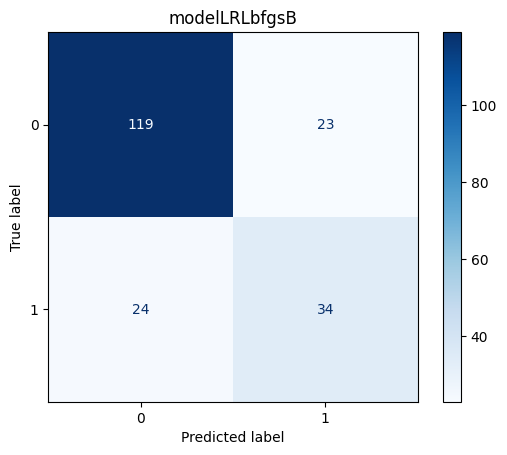

              precision    recall  f1-score   support

           0       0.83      0.84      0.84       142
           1       0.60      0.59      0.59        58

    accuracy                           0.77       200
   macro avg       0.71      0.71      0.71       200
weighted avg       0.76      0.77      0.76       200



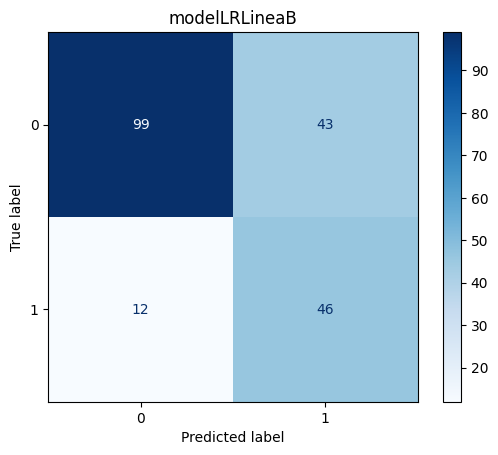

              precision    recall  f1-score   support

           0       0.89      0.70      0.78       142
           1       0.52      0.79      0.63        58

    accuracy                           0.72       200
   macro avg       0.70      0.75      0.70       200
weighted avg       0.78      0.72      0.74       200



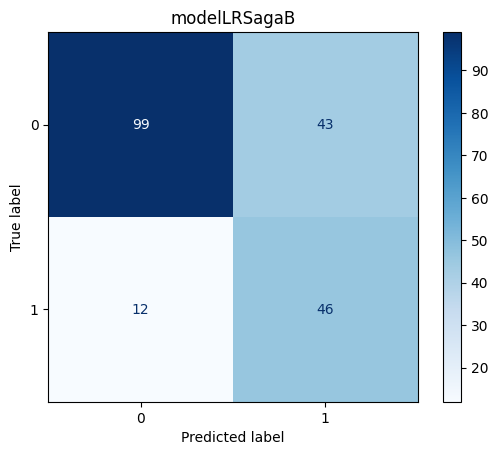

              precision    recall  f1-score   support

           0       0.89      0.70      0.78       142
           1       0.52      0.79      0.63        58

    accuracy                           0.72       200
   macro avg       0.70      0.75      0.70       200
weighted avg       0.78      0.72      0.74       200



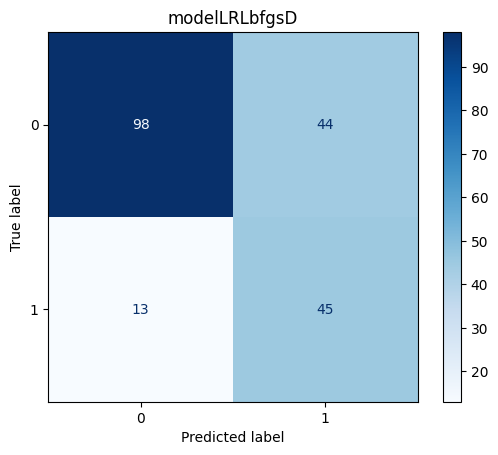

              precision    recall  f1-score   support

           0       0.88      0.69      0.77       142
           1       0.51      0.78      0.61        58

    accuracy                           0.71       200
   macro avg       0.69      0.73      0.69       200
weighted avg       0.77      0.71      0.73       200



In [25]:
# Crear un diccionario de modelos
models = {
    'modelLRLbfgsB': [modelLRLbfgsB, y_predLbfgsB],
    'modelLRLineaB': [modelLRLineaB, y_predLineaB],
    'modelLRSagaB': [modelLRSagaB, y_predSagaB],
    'modelLRLbfgsD': [modelLRLbfgsD, y_predLbfgsD],
}

# Para cada modelo se se extrae un elemento del diccionario models
for model_name, (model, y_pred) in models.items():

    # Calcular la matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # Crear la visualización de la matriz de confusión
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))

    # Mostrar la visualización
    disp.plot(cmap='Blues')

    # Mostrar el título usando matplotlib
    plt.title(model_name)

    # Mostrar la figura
    plt.show()

    # Mostrar el informe de clasificación
    print(classification_report(y_test, y_pred))


#### ROC - Receiver Operating Characteristic

AUC: 0.83


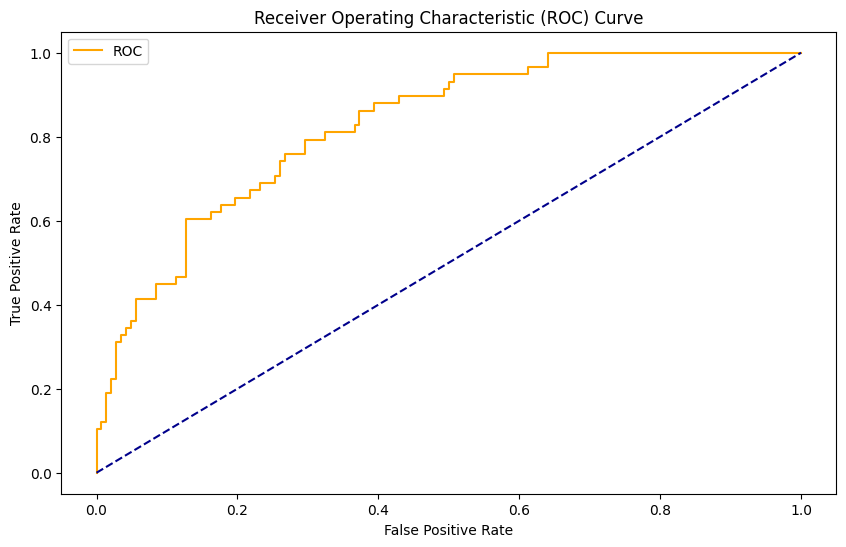

In [30]:
#Curva ROC para un modelo

fig = plt.figure(figsize=(10,6))

# Predecir las probabilidades de la clase positiva usando el modelo de regresión logística entrenado
probs = modelLRLineaB.predict_proba(X_test)

# Tomar las probabilidades de la clase positiva solamente
probs = probs[:, 1]

# Calcular el área bajo la curva ROC
auc = roc_auc_score(y_test, probs*(1))

# Imprimir el valor del AUC
print('AUC: %.2f' % auc)

# Calcular la curva ROC usando los valores verdaderos y las probabilidades predichas
fpr, tpr, thresholds = roc_curve(y_test, probs*(1))

# Graficar la curva ROC
plot_roc_curve(fpr, tpr)


##Nota: es necesario que la variable de salida sea numérica, sino debe transformarse

### Guardar modelo

In [31]:
#Se guarda el modelo de Regresión logística

MODEL_FILE_NAME = 'LRLineaB.pkl'
local_model_path = os.path.join(MODELS_CLASIFICACION_PATH, MODEL_FILE_NAME)

joblib.dump(modelLRLineaB,  local_model_path)

['modelos/clasificacion/LRLineaB.pkl']

#### Referencias


- Regresion Logística

    - https://realpython.com/logistic-regression-python/#regularization
    
    
- Parámetros Regresion Logística

    - https://holypython.com/log-reg/logistic-regression-optimization-parameters/


- *scikit-learn:*   
    - https://scikit-learn.org/stable/modules/svm.html



- *Gráficas con  seaborn:*
    - https://ichi.pro/es/como-utilizar-python-seaborn-para-analisis-de-datos-exploratorios-28897898172180



- *Analítica de grandes datos:*
    - https://jdvelasq.github.io/courses/analitica-de-grandes-datos/index.html